# Bench MPI + OpenMP (ex02)

This notebook runs the two binaries and compares timings.
We keep it short: N from 1 to 14 (max), and we compare:
- MPI: fixed number of ranks
- OpenMP: fixed number of threads

Output CSV: `bench_results_mpi_omp.csv`

Order:
1. Setup (tqdm + build both)
2. Run bench and write CSV
3. Plot time vs N (log scale)
4. Cleanup `.o` files (keeps the executables)

In [1]:
# Setup (MPI + OpenMP)

import re
import csv
import sys
import subprocess
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('.').resolve()
MPI_DIR = ROOT / 'mpi'
OMP_DIR = ROOT / 'open_mp'

MPI_EXE = MPI_DIR / 'mpi_ex02'
OMP_EXE = OMP_DIR / 'openmp_ex02'

OUT_CSV = ROOT / 'bench_results_mpi_omp.csv'

def sh(cmd, *, cwd=ROOT, check=True):
    p = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if check and p.returncode != 0:
        print('CWD:', cwd)
        print('STDOUT:')
        print(p.stdout)
        print('STDERR:')
        print(p.stderr)
        raise RuntimeError(f'command failed: {cmd}')
    return p.stdout

# tqdm install if missing (no try/except)
if importlib.util.find_spec('tqdm') is None:
    sh([sys.executable, '-m', 'pip', 'install', 'tqdm'])
from tqdm import tqdm

# build both (and remove .o files but keep exe)
sh(['make', 're'], cwd=MPI_DIR)
sh(['make', 'clean'], cwd=MPI_DIR)
sh(['make', 're'], cwd=OMP_DIR)
sh(['make', 'clean'], cwd=OMP_DIR)

if not MPI_EXE.exists():
    raise RuntimeError('MPI exe missing after build')
if not OMP_EXE.exists():
    raise RuntimeError('OpenMP exe missing after build')

print('OK MPI exe ->', MPI_EXE)
print('OK OMP exe ->', OMP_EXE)

OK MPI exe -> /Users/aurele/AAA_PRO/please/ex02/mpi/mpi_ex02
OK OMP exe -> /Users/aurele/AAA_PRO/please/ex02/open_mp/openmp_ex02


In [11]:
# Bench: N=1..14 (max), compare MPI vs OpenMP

N_MIN = 1
N_MAX = 14

# use the max for both
MPI_NP = N_MAX
OMP_THREADS = 50

_re_mpi_time = re.compile(r'^time mpi \(max\):\s*([0-9.]+)\s*s\s*$', re.M)
_re_omp_time = re.compile(r'^time omp\s*:\s*([0-9.]+)\s*s\s*$', re.M)
_re_omp_time_alt = re.compile(r'^time omp\s*\s*:\s*([0-9.]+)\s*s\s*$', re.M)

def parse_mpi_time(out: str) -> float:
    m = _re_mpi_time.search(out)
    if not m:
        raise ValueError('could not parse MPI time')
    return float(m.group(1))

def parse_omp_time(out: str) -> float:
    m = _re_omp_time.search(out)
    if m:
        return float(m.group(1))
    m2 = _re_omp_time_alt.search(out)
    if m2:
        return float(m2.group(1))
    # our program prints: "time omp   : ..." so match that too
    m3 = re.search(r'^time omp\s*:\s*([0-9.]+)\s*s\s*$', out, re.M)
    if m3:
        return float(m3.group(1))
    m4 = re.search(r'^time omp\s+:\s*([0-9.]+)\s*s\s*$', out, re.M)
    if m4:
        return float(m4.group(1))
    m5 = re.search(r'^time omp\s*\s*:\s*([0-9.]+)\s*s\s*$', out, re.M)
    if m5:
        return float(m5.group(1))
    m6 = re.search(r'^time omp\s*\s*:\s*([0-9.]+)\s*s\s*$', out, re.M)
    if m6:
        return float(m6.group(1))
    # last fallback specific to our print format
    m7 = re.search(r'^time omp\s+\s*:\s*([0-9.]+)\s*s\s*$', out, re.M)
    if m7:
        return float(m7.group(1))
    raise ValueError('could not parse OpenMP time')

rows = []
for n in tqdm(range(N_MIN, N_MAX + 1), desc='N'):
    # MPI run (fixed np)
    out_mpi = sh(['mpirun', '-np', str(MPI_NP), str(MPI_EXE), str(n), '-2', '1', '2', '0'], cwd=ROOT)
    t_mpi = parse_mpi_time(out_mpi)
    rows.append({'model': 'mpi', 'n': n, 'workers': MPI_NP, 'time_s': t_mpi})

    # OpenMP run (fixed threads)
    out_omp = sh([str(OMP_EXE), str(n), '-2', '1', '2', str(OMP_THREADS), '0'], cwd=ROOT)
    t_omp = parse_omp_time(out_omp)
    rows.append({'model': 'openmp', 'n': n, 'workers': OMP_THREADS, 'time_s': t_omp})

with OUT_CSV.open('w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['model', 'n', 'workers', 'time_s'])
    w.writeheader()
    w.writerows(rows)

print('OK wrote', OUT_CSV, 'rows=', len(rows))

N: 100%|██████████| 14/14 [00:01<00:00,  8.05it/s]

OK wrote /Users/aurele/AAA_PRO/please/ex02/bench_results_mpi_omp.csv rows= 28


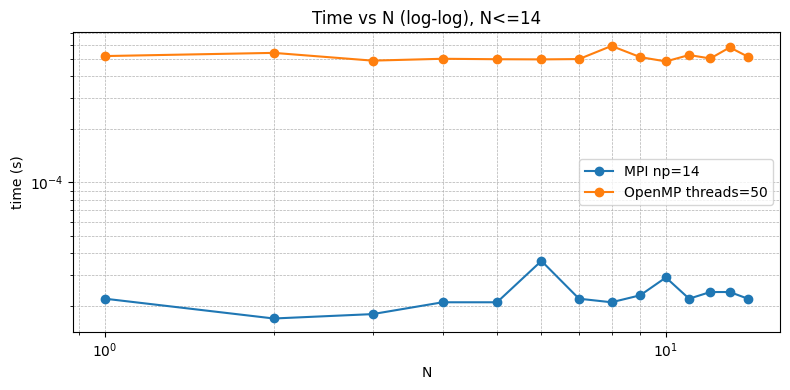

In [12]:
# Plot: time vs N (log scale) - MPI vs OpenMP

def series(rows, model):
    xs = [r['n'] for r in rows if r['model'] == model]
    ys = [r['time_s'] for r in rows if r['model'] == model]
    return xs, ys

x_mpi, y_mpi = series(rows, 'mpi')
x_omp, y_omp = series(rows, 'openmp')

# log scale can't do zeros, so clamp very small values
eps = 1e-9
y_mpi_p = [max(eps, v) for v in y_mpi]
y_omp_p = [max(eps, v) for v in y_omp]

plt.figure(figsize=(8, 4))
plt.plot(x_mpi, y_mpi_p, marker='o', label=f'MPI np={MPI_NP}')
plt.plot(x_omp, y_omp_p, marker='o', label=f'OpenMP threads={OMP_THREADS}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('time (s)')
plt.title('Time vs N (log-log), N<=14')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cleanup: remove .o files (keep executables)

sh(['make', 'clean'], cwd=MPI_DIR)
sh(['make', 'clean'], cwd=OMP_DIR)
print('OK clean done (kept exes)')

OK clean done (kept exe)
